In [ ]:
# Importing required libraries and loading the transaction dataset 
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


df = pd.read_csv("../data/spending_patterns_detailed.csv")


df.head()

,Customer ID,Category,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,CUST_0159,Groceries,Milk,1,1.28,1.28,Debit Card,Mobile App,2024-11-13
1,CUST_0017,Friend Activities,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023-05-04
2,CUST_0094,Housing and Utilities,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023-12-16
3,CUST_0162,Fitness,Yoga Class,5,11.24,56.18,Cash,In-store,2024-01-28
4,CUST_0129,Gifts,Flowers,3,43.71,131.12,Debit Card,In-store,2023-07-28


In [ ]:
# Performing initial data inspection to understand the dataset structure,
# data types, summary statistics, and to check for any missing values.

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer ID       10000 non-null  object 
 1   Category          10000 non-null  object 
 2   Item              10000 non-null  object 
 3   Quantity          10000 non-null  int64  
 4   Price Per Unit    10000 non-null  float64
 5   Total Spent       10000 non-null  float64
 6   Payment Method    10000 non-null  object 
 7   Location          10000 non-null  object 
 8   Transaction Date  10000 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 703.3+ KB


Customer ID         0
Category            0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Total Revenue: 25347508.900000002


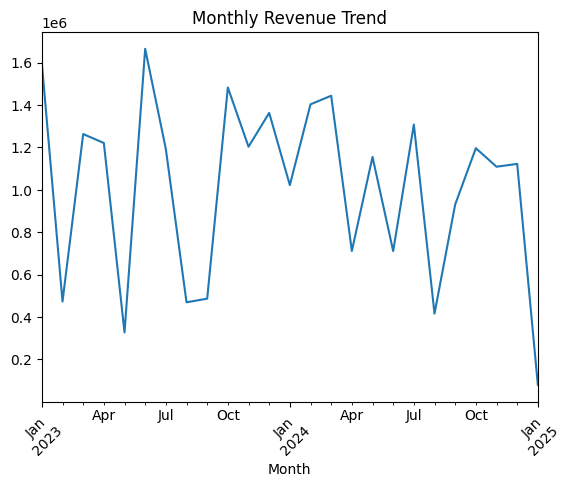

Top 10 Customers:
 Customer ID
CUST_0033    676346.70
CUST_0163    589432.75
CUST_0040    515134.58
CUST_0034    504948.72
CUST_0039    498365.86
CUST_0104    475648.95
CUST_0191    453758.07
CUST_0021    431411.44
CUST_0032    426895.05
CUST_0200    382732.97
Name: Total Spent, dtype: float64


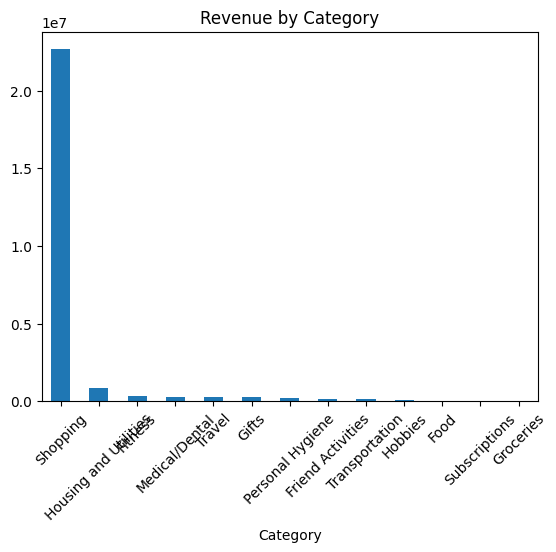

In [ ]:

# Converting transaction dates into datetime format for time-based analysis
# Creating a monthly period column to evaluate revenue trends over time
# Calculating total revenue to understand overall business performance

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df['Month'] = df['Transaction Date'].dt.to_period('M')

total_revenue = df['Total Spent'].sum()
print("Total Revenue:", total_revenue)

monthly_revenue = df.groupby('Month')['Total Spent'].sum()
monthly_revenue.plot(title="Monthly Revenue Trend", kind='line')
plt.xticks(rotation=45)
plt.show()

top_customers = df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers:\n", top_customers)

category_revenue = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar', title="Revenue by Category")
plt.xticks(rotation=45)
plt.show()
# - Identifying top customers by total spending
# - Analyzing revenue contribution by product category

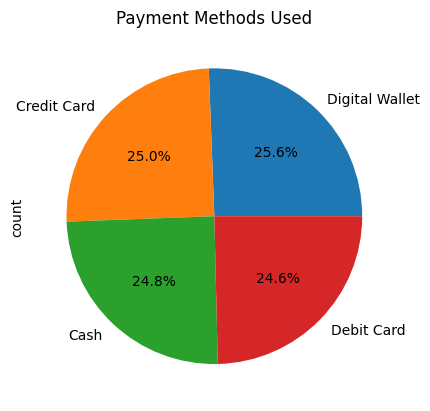

In [ ]:
# Analyzing customer payment behavior to understand the distribution 
# of payment methods and identify dominant transaction channels.
payment_counts = df['Payment Method'].value_counts()
payment_counts.plot(kind='pie', autopct='%1.1f%%', title="Payment Methods Used")
plt.show()

In [ ]:
# Calculating the average transaction value to assess 
# typical customer spending behavior per purchase.
avg_transaction = df['Total Spent'].mean()
print("Average Spent per Transaction:", round(avg_transaction, 2))

Average Spent per Transaction: 2534.75
